# CAS KAGGLE: `Detection of Pistachio Types By Classifier Models`


## INTRODUCCIÓ

## BASE DE DADES

En el nostre Cas Kaggle hem triat una base de dades de pistatxos, que a partir atributs d'aquests extrets d'imatges processades té l'objectiu de predir de quin tipus de pistatxo es tracta `Kirmizi` o  bé `Siit`.

https://www.kaggle.com/datasets/amirhosseinmirzaie/pistachio-types-detection/data

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./archive/pistachio.csv")


In [4]:
df.describe(include="all")

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
count,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kirmizi_Pistachio
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,998
mean,79871.952852,1421.797588,446.206444,238.193128,0.840347,317.790000,0.940103,84947.671129,0.716055,1.899342,0.570831,0.712841,0.005704,0.003017,0.510097,0.955185,NaN
std,12968.217051,373.408835,31.885328,30.426445,0.049026,26.571699,0.050006,13081.742551,0.052534,0.241253,0.211514,0.044230,0.000810,0.000334,0.063391,0.051735,NaN
min,29808.000000,858.363000,321.425500,133.509600,0.504900,194.814600,0.588000,37935.000000,0.427200,1.158500,0.062800,0.476000,0.004000,0.002400,0.226600,0.620400,NaN
25%,71898.500000,1169.633225,426.554100,217.875475,0.817500,302.562375,0.920250,76357.750000,0.688100,1.736325,0.372325,0.682000,0.005200,0.002800,0.465125,0.944200,NaN
50%,79795.000000,1260.785500,448.453150,235.888750,0.850250,318.744650,0.953800,84973.000000,0.726100,1.899550,0.643850,0.709750,0.005600,0.003000,0.503750,0.972800,NaN
75%,88980.000000,1599.479000,467.515200,257.433625,0.875375,336.590000,0.976300,93660.750000,0.753600,2.068575,0.744450,0.741600,0.006100,0.003200,0.549975,0.986800,NaN


In [5]:
df.dtypes

AREA               int64
PERIMETER        float64
MAJOR_AXIS       float64
MINOR_AXIS       float64
ECCENTRICITY     float64
EQDIASQ          float64
SOLIDITY         float64
CONVEX_AREA        int64
EXTENT           float64
ASPECT_RATIO     float64
ROUNDNESS        float64
COMPACTNESS      float64
SHAPEFACTOR_1    float64
SHAPEFACTOR_2    float64
SHAPEFACTOR_3    float64
SHAPEFACTOR_4    float64
Class             object
dtype: object

In [6]:
df['Class'].value_counts()

Class
Kirmizi_Pistachio    998
Siit_Pistachio       720
Name: count, dtype: int64

In [7]:
df.isna().sum()

AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
Class            0
dtype: int64

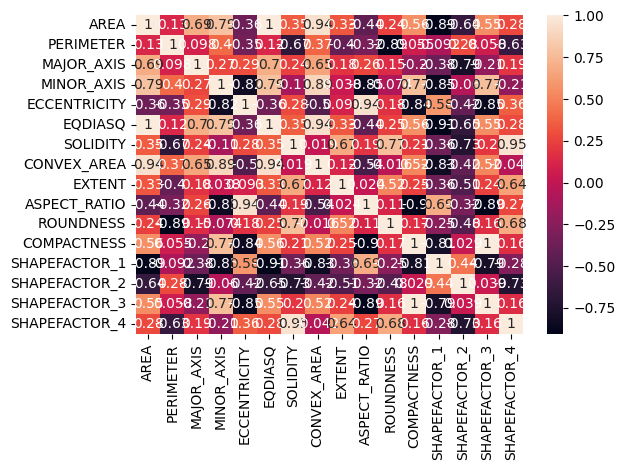

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.tight_layout()
plt.show()

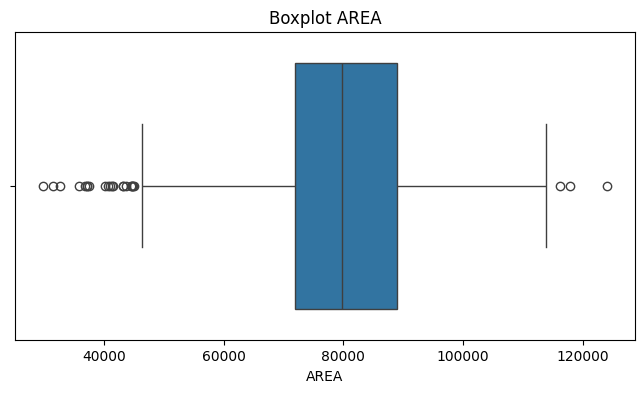

Nombre d'outliers per columna:
AREA             11
PERIMETER        22
MAJOR_AXIS       11
MINOR_AXIS       17
ECCENTRICITY     29
EQDIASQ          17
SOLIDITY         33
CONVEX_AREA      11
EXTENT           19
ASPECT_RATIO     11
ROUNDNESS         0
COMPACTNESS      13
SHAPEFACTOR_1    21
SHAPEFACTOR_2    26
SHAPEFACTOR_3    15
SHAPEFACTOR_4    38
dtype: int64
Files originals: 1718
Files després de eliminar outliers: 1608


In [9]:
from scipy.stats import zscore

# Boxplot per detectar outliers visuals per una variable (exemple: AREA)
plt.figure(figsize=(8,4))
sns.boxplot(x=df['AREA'])
plt.title('Boxplot AREA')
plt.show()

# Calcular z-score per totes les columnes numèriques
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
z_scores = np.abs(df[num_cols].apply(zscore))

# Mostrar quins valors són outliers (|z|>3)
outliers = (z_scores > 3)
print("Nombre d'outliers per columna:")
print(outliers.sum())

# Exemple per eliminar files que tenen outliers en qualsevol variable
df_clean = df[(z_scores < 3).all(axis=1)]
print("Files originals:", df.shape[0])
print("Files després de eliminar outliers:", df_clean.shape[0])
